In [2]:
import sys, os

# Path to your project root (the folder that contains pointmaze/, rpmml_project/, etc.)
PROJECT_ROOT = "/scratch/network/dd6849/rpmml-project/timeskip-diffuser/src/timeskip_diffuser"

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("PYTHONPATH updated with:", PROJECT_ROOT)

PYTHONPATH updated with: /scratch/network/dd6849/rpmml-project/timeskip-diffuser/src/timeskip_diffuser


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import random
from eqnet_independent_copy import EqNet, GaussianDiffusion, DiffuserTrainer, DiffuserPlanner, CompositeReward, expand_spline_from_skip_list, StartReachingReward, GoalReachingReward, SkipTotalTimeSkipPenalty, CurvaturePenalty, OfflineSkipDataset
from point_maze_skip import MinariTrajectoryDatasetWithPseudoActions
import torch
from matplotlib.patches import Rectangle
import mujoco

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

USE_POSITIONAL_ENCODING = False

print("\n" + "=" * 80)
print("EQ-NET CONFIGURATION")
print("=" * 80)
print(f"Positional Encoding: {USE_POSITIONAL_ENCODING}")
print("Architecture: Local convolutions (no downsampling) for shift equivariance")
print("Using MinariTrajectoryDatasetWithPseudoActions (pos + skip as action)")

    # ========================================================================
    # DATA
    # ========================================================================

# Use pseudo-action dataset
dataset = MinariTrajectoryDatasetWithPseudoActions(
    "D4RL/pointmaze/medium-v2", horizon=32, n_chunks_frac= 0.5
)
print(f"\nDataset size: {len(dataset)} trajectory windows")
print(f"Trajectory dim (pos+skip): {dataset.traj_dim}")


Using device: cuda

EQ-NET CONFIGURATION
Positional Encoding: False
Architecture: Local convolutions (no downsampling) for shift equivariance
Using MinariTrajectoryDatasetWithPseudoActions (pos + skip as action)

Dataset size: 363160 trajectory windows
Trajectory dim (pos+skip): 3


In [5]:
# ========================================================================
    # MODEL
    # ========================================================================

eqnet = EqNet(
        state_dim=dataset.traj_dim,
        hidden_dim=128,
        time_dim=32,
        n_layers=10,  # Deep but local
    )

diffusion = GaussianDiffusion(timesteps=200)

print(f"\nModel parameters: {sum(p.numel() for p in eqnet.parameters()):,}")



Model parameters: 1,506,179


In [6]:
# ========================================================================
# TRAINING
# ========================================================================

trainer = DiffuserTrainer(
        model = eqnet,
        diffusion = diffusion,
        dataset=dataset,
        device = device,
    )

TRAIN_NEW = False
if TRAIN_NEW:
    print("\n" + "=" * 80)
    print("TRAINING")
    print("=" * 80)
    trainer.train(epochs=100, save_every=1)
else:
    print("\nLoading pre-trained model...")
    try:
        trainer.load("/scratch/network/dd6849/rpmml-project/checkpoints/diffuser_flat_eqnet_independent_epoch_100_fixed.pt")
        print("Loaded checkpoint successfully")
    except:
        print("No checkpoint found, using random initialization")

trainer.use_ema_for_inference()


Loading pre-trained model...
Loaded checkpoint successfully
Switched to EMA parameters for inference


In [7]:
# ========================================================================
# PLANNING
# ========================================================================

planner = DiffuserPlanner(eqnet, diffusion, dataset, device=device)

current = np.array([-0.5, -1.5, 0, 0])
goal = np.array([-1.5, 1.5])

reward_fn = CompositeReward(
    [
        StartReachingReward(current[:2], reward_scale=5.0),
        GoalReachingReward(goal, reward_scale=5.0),
        SkipTotalTimeSkipPenalty(reward_scale=0.0),
        CurvaturePenalty(reward_scale=0.0),
    ]
)

print("\n" + "=" * 80)
print("PLANNING WITH EQ-NET (pos + skip)")
print("=" * 80)

# Experiment 1: standard planning
print("\n--- Experiment 1: Standard Planning ---")
traj = planner.plan_and_reconstruct(
    current,
    goal,
    reward_fn=reward_fn,
    horizon=32,
    guidance_scale=1.0,
    condition_on_start=True,
    condition_on_goal=True,
    conditioning_schedule="constant",
    conditioning_strength=0.9,
    spline_func=expand_spline_from_skip_list,
)
coarse, = traj["coarse"],
coarse_pos= traj["coarse_pos"] 
coarse_skip=traj["coarse_skip"]              # (H,)
skip = traj["skip_list"]     # [(pos_i, skip_i)]
pos_dense=traj["pos_dense"]           # (N,2)
vel_dense=traj["vel_dense"]           # (N,2)
acc_dense=traj["acc_dense"]           # (N,2)  
print(f"Start (actual): {pos_dense[0]}")
print(f"Start (target): {current[:2]}")
print(f"Start error: {np.linalg.norm(pos_dense[0] - current[:2]):.4f}")
print(f"End: {pos_dense[-1]}")
print(f"Goal: {goal}")
print(f"Goal error: {np.linalg.norm(pos_dense[-1] - goal):.4f}")
print("\n" + "=" * 80)
print("EXPERIMENTS COMPLETE")
print("=" * 80)
print(pos_dense)


PLANNING WITH EQ-NET (pos + skip)

--- Experiment 1: Standard Planning ---
Start (actual): [-0.50219658 -1.49874035]
Start (target): [-0.5 -1.5]
Start error: 0.0025
End: [-1.40593337  1.54589884]
Goal: [-1.5  1.5]
Goal error: 0.1047

EXPERIMENTS COMPLETE
[[-0.50219658 -1.49874035]
 [-0.4952574  -1.49681026]
 [-0.45401244 -1.50343998]
 [-0.38011526 -1.52254964]
 [-0.30621808 -1.5416593 ]
 [-0.24816487 -1.55480202]
 [-0.21431795 -1.5611338 ]
 [-0.16754588 -1.5694883 ]
 [-0.10224328 -1.58077312]
 [-0.03694067 -1.59205793]
 [ 0.01219995 -1.60042924]
 [ 0.04365349 -1.60680422]
 [ 0.09234584 -1.61378241]
 [ 0.18100272 -1.62521263]
 [ 0.27542611 -1.63862299]
 [ 0.35831649 -1.64807306]
 [ 0.41237436 -1.64762242]
 [ 0.44507483 -1.6422828 ]
 [ 0.47777531 -1.63694318]
 [ 0.50051698 -1.6284168 ]
 [ 0.51972238 -1.61511795]
 [ 0.53460053 -1.60202811]
 [ 0.54250385 -1.59225934]
 [ 0.54915451 -1.57985802]
 [ 0.55824887 -1.57899181]
 [ 0.55950136 -1.54440465]
 [ 0.54656579 -1.44184412]
 [ 0.53251294 -

In [8]:
env = dataset.dataset.recover_environment()

def unwrap_env(env):
    while hasattr(env, "env"):
        env = env.env
    return env

env = unwrap_env(env)

mj_model_medium = env.model
mj_data = env.data

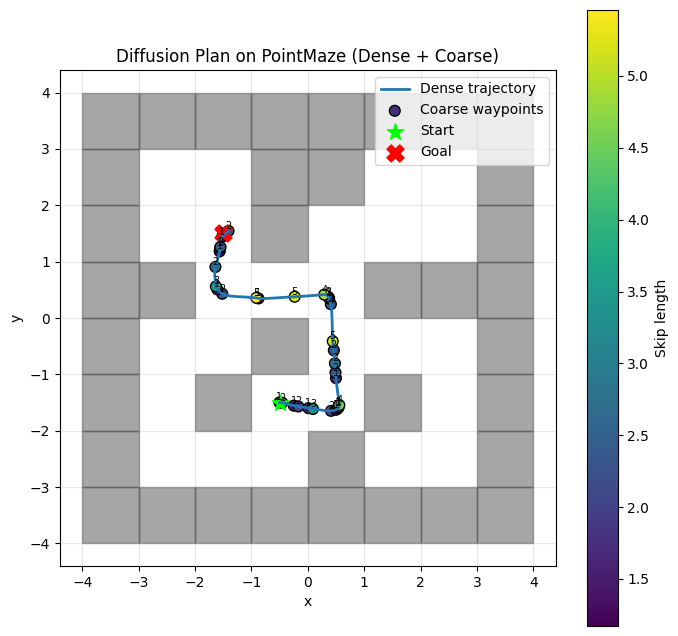

In [9]:
# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# ===========================================================
# 1) Dense trajectory
# ===========================================================
ax.plot(
    pos_dense[:, 0],
    pos_dense[:, 1],
    linewidth=2,
    color="tab:blue",
    label="Dense trajectory"
)

# ===========================================================
# 2) Coarse waypoints (colored by skip)
# ===========================================================
sc = ax.scatter(
    coarse_pos[:, 0],
    coarse_pos[:, 1],
    c=coarse_skip,
    s=60,
    cmap="viridis",
    edgecolors="k",
    label="Coarse waypoints"
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Skip length")

# Annotate skip values
for i, (x, y) in enumerate(coarse_pos):
    ax.text(x, y, f"{int(coarse_skip[i])}", fontsize=7, ha="center", va="bottom")

# ===========================================================
# 3) Start and Goal
# ===========================================================
ax.scatter(current[0], current[1], s=150, marker="*", color="lime",  label="Start")
ax.scatter(goal[0],    goal[1],    s=150, marker="X", color="red",   label="Goal")

# ===========================================================
# 4) Render MuJoCo maze walls
# ===========================================================
for geom_id in range(mj_model_medium.ngeom):

    name = mujoco.mj_id2name(mj_model_medium, mujoco.mjtObj.mjOBJ_GEOM, geom_id)

    if name is None or ("block" not in name):
        continue

    pos = mj_model_medium.geom_pos[geom_id]      # (x,y,z) center
    size = mj_model_medium.geom_size[geom_id]    # half sizes (hx,hy,hz)

    cx, cy = pos[:2]
    hx, hy = size[:2]

    rect = Rectangle(
        (cx - hx, cy - hy),
        2 * hx,
        2 * hy,
        color="black",
        alpha=0.35,
        zorder=0
    )
    ax.add_patch(rect)

# ===========================================================
# Final styling
# ===========================================================
ax.set_title("Diffusion Plan on PointMaze (Dense + Coarse)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", "box")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

# # Mazes are usually within [-2.5, 2.5]
# ax.set_xlim(-2.5, 2.5)
# ax.set_ylim(-2.5, 2.5)

plt.show()

In [10]:
# ============================================================
# CONFIG
# ============================================================
NUM_RUNS = 20
HORIZON  = 32

current = np.array([-0.5, -1.5, 0, 0])
goal    = np.array([-1.5,  1.5])

planner = DiffuserPlanner(eqnet, diffusion, dataset, device=device)

reward_fn = CompositeReward(
    [
        StartReachingReward(current[:2], reward_scale=5.0),
        GoalReachingReward(goal, reward_scale=5.0),
        SkipTotalTimeSkipPenalty(reward_scale=0.0),
        CurvaturePenalty(reward_scale=0.0),
    ]
)

# ============================================================
# RUN PLANNING N TIMES
# ============================================================
runs = []
print(f"\nRunning {NUM_RUNS} planning attempts...\n")

for i in range(NUM_RUNS):
    print(f" → Run {i+1}/{NUM_RUNS}")

    traj = planner.plan_and_reconstruct(
        current,
        goal,
        reward_fn=reward_fn,
        horizon=HORIZON,
        guidance_scale=1.0,
        condition_on_start=True,
        condition_on_goal=True,
        conditioning_schedule="constant",
        conditioning_strength=0.9,
        spline_func=expand_spline_from_skip_list,
    )

    runs.append({
        "pos_dense": traj["pos_dense"],
        "coarse_pos": traj["coarse_pos"],
        "coarse_skip": traj["coarse_skip"],
    })

print("\nAll planning runs complete.\n")

# ============================================================
# MULTI-RUN VISUALIZER USING YOUR EXACT STYLE
# ============================================================
fig, ax = plt.subplots(figsize=(8, 8))

# Color per run (colormap)
colors = plt.cm.tab10(np.linspace(0, 1, NUM_RUNS))

# Draw MuJoCo maze walls
for geom_id in range(mj_model.ngeom):
    name = mujoco.mj_id2name(mj_model, mujoco.mjtObj.mjOBJ_GEOM, geom_id)
    if name is None or ("block" not in name):
        continue

    pos  = mj_model.geom_pos[geom_id]
    size = mj_model.geom_size[geom_id]
    cx, cy = pos[:2]
    hx, hy = size[:2]

    rect = Rectangle(
        (cx - hx, cy - hy),
        2 * hx,
        2 * hy,
        color="black",
        alpha=0.35,
        zorder=0
    )
    ax.add_patch(rect)

# ============================================================
# Plot all trajectories
# ============================================================
for i, run in enumerate(runs):
    pos_dense   = run["pos_dense"]
    coarse_pos  = run["coarse_pos"]
    coarse_skip = run["coarse_skip"]

    color = colors[i % len(colors)]

    # 1) Dense trajectory
    ax.plot(
        pos_dense[:, 0],
        pos_dense[:, 1],
        linewidth=1.8,
        color=color,
        alpha=0.7,
        label=f"Run {i+1}"
    )

    # 2) Coarse waypoints (colored by skip)
    sc = ax.scatter(
        coarse_pos[:, 0],
        coarse_pos[:, 1],
        c=coarse_skip,
        cmap="viridis",
        s=50,
        edgecolors="k",
        alpha=0.9
    )

    # 3) Skip annotation
    for j, (x, y) in enumerate(coarse_pos):
        ax.text(x, y, f"{int(coarse_skip[j])}", fontsize=7,
                ha="center", va="bottom", color="black")

# ============================================================
# Start and goal
# ============================================================
ax.scatter(current[0], current[1], s=200, marker="*", color="lime", label="Start")
ax.scatter(goal[0],    goal[1],    s=200, marker="X", color="red",  label="Goal")

# ============================================================
# Final styling
# ============================================================
ax.set_title(f"EQ-Net Diffusion Planning — {NUM_RUNS} Runs")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", "box")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=8, frameon=True)

# ax.set_xlim(-2.5, 2.5)
# ax.set_ylim(-2.5, 2.5)

plt.colorbar(sc, ax=ax, label="Skip Length")
plt.tight_layout()
plt.show()


Running 20 planning attempts...

 → Run 1/20


KeyboardInterrupt: 

In [11]:
print(env.maze.maze_map)

[[1, 1, 1, 1, 1, 1, 1, 1], [1, 0, 0, 1, 1, 0, 0, 1], [1, 0, 0, 1, 0, 0, 0, 1], [1, 1, 0, 0, 0, 1, 1, 1], [1, 0, 0, 1, 0, 0, 0, 1], [1, 0, 1, 0, 0, 1, 0, 1], [1, 0, 0, 0, 1, 0, 0, 1], [1, 1, 1, 1, 1, 1, 1, 1]]


In [12]:
import numpy as np
import mujoco

def get_wall_rectangles(mj_model):
    """
    Returns a list of wall rectangles as (xmin, xmax, ymin, ymax)
    in WORLD coordinates.
    """
    walls = []

    for geom_id in range(mj_model.ngeom):
        name = mujoco.mj_id2name(
            mj_model, mujoco.mjtObj.mjOBJ_GEOM, geom_id
        )

        if name is None or "block" not in name:
            continue

        pos = mj_model.geom_pos[geom_id]      # (x, y, z)
        size = mj_model.geom_size[geom_id]    # (hx, hy, hz)

        cx, cy = pos[:2]
        hx, hy = size[:2]

        walls.append((
            cx - hx, cx + hx,
            cy - hy, cy + hy,
        ))

    return walls


In [13]:
def compute_maze_bounds(walls, margin=0.1):
    """
    Compute a bounding box that encloses the maze.
    """
    xs = []
    ys = []
    for xmin, xmax, ymin, ymax in walls:
        xs.extend([xmin, xmax])
        ys.extend([ymin, ymax])

    xmin, xmax = min(xs), max(xs)
    ymin, ymax = min(ys), max(ys)

    return (
        xmin + margin,
        xmax - margin,
        ymin + margin,
        ymax - margin,
    )


In [14]:
def get_inflated_wall_aabbs(mj_model, inflation=1.10):
    """
    Returns list of (xmin, xmax, ymin, ymax) for inflated wall geoms.
    """
    walls = []

    for geom_id in range(mj_model.ngeom):
        name = mujoco.mj_id2name(
            mj_model, mujoco.mjtObj.mjOBJ_GEOM, geom_id
        )

        if name is None or "block" not in name:
            continue

        pos  = mj_model.geom_pos[geom_id]    # (x,y,z)
        size = mj_model.geom_size[geom_id]   # (hx,hy,hz)

        cx, cy = pos[:2]
        hx, hy = size[:2]

        hx += inflation
        hy += inflation

        walls.append((
            cx - hx, cx + hx,
            cy - hy, cy + hy
        ))

    return walls


In [15]:
def point_in_any_wall(p, walls):
    x, y = p
    for xmin, xmax, ymin, ymax in walls:
        if (xmin <= x <= xmax and ymin <= y <= ymax) or (x >= 4.0) or (y >= 4.0)or (x <= -4.0)or (y <= -4.0):
            return True
    return False


In [16]:
def sample_safe_point(
    xlim,
    ylim,
    wall_aabbs,
    max_tries=1000,
):
    """
    Uniformly samples a point that is NOT inside inflated walls.
    """
    for _ in range(max_tries):
        x = np.random.uniform(*xlim)
        y = np.random.uniform(*ylim)

        if not point_in_any_wall((x, y), wall_aabbs):
            return np.array([x, y], dtype=np.float32)

    raise RuntimeError("Failed to sample collision-free point")


In [17]:
def sample_safe_start_goal(
    mj_model,
    xlim=(-4.5, 4.5),
    ylim=(-4.5, 4.5),
    inflation=1.05,
):
    wall_aabbs = get_inflated_wall_aabbs(mj_model, inflation)

    start = sample_safe_point(xlim, ylim, wall_aabbs)
    goal  = sample_safe_point(xlim, ylim, wall_aabbs)

    return start, goal


In [18]:
def sample_start_goal_pairs(
    mj_model,
    n=100,
    xlim=(-4.5, 4.5),
    ylim=(-4.5, 4.5),
    inflation=1.05,
):
    wall_aabbs = get_inflated_wall_aabbs(mj_model, inflation)

    starts = np.zeros((n, 2))
    goals  = np.zeros((n, 2))

    for i in range(n):
        starts[i] = sample_safe_point(xlim, ylim, wall_aabbs)
        goals[i]  = sample_safe_point(xlim, ylim, wall_aabbs)

    return starts, goals, wall_aabbs


In [19]:
def plot_start_goals_on_maze(
    mj_model,
    starts,
    goals,
    wall_aabbs,
    xlim=(-4.0, 4.0),
    ylim=(-4.0, 4.0),
):
    fig, ax = plt.subplots(figsize=(8, 8))

    # Draw walls
    for xmin, xmax, ymin, ymax in wall_aabbs:
        rect = Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            color="black",
            alpha=0.35,
            zorder=0,
        )
        ax.add_patch(rect)

    # Plot points
    ax.scatter(starts[:, 0], starts[:, 1],
               c="lime", s=30, label="Starts", zorder=2)
    ax.scatter(goals[:, 0], goals[:, 1],
               c="red", s=30, label="Goals", zorder=2)

    # Optional lines
    for s, g in zip(starts, goals):
        ax.plot([s[0], g[0]], [s[1], g[1]],
                color="gray", alpha=0.2, linewidth=0.8)

    ax.set_aspect("equal")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title("Sampled Start–Goal Pairs (Wall-Safe)")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.show()


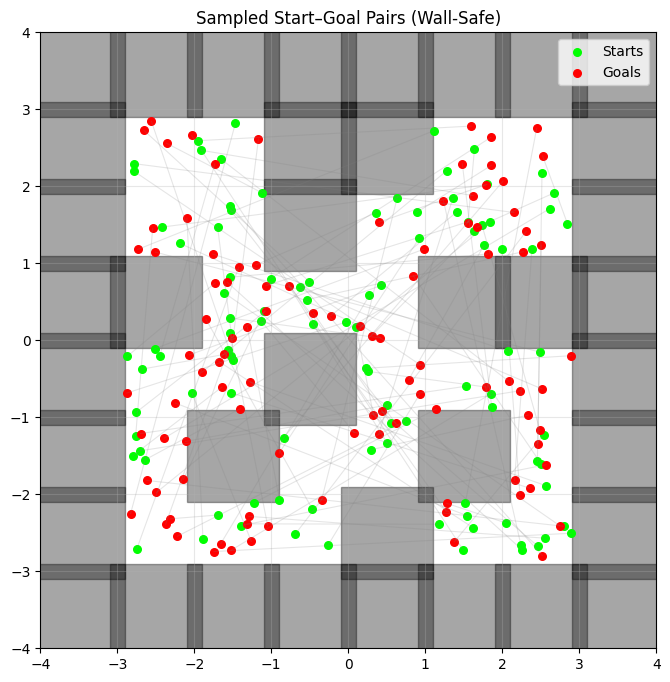

In [20]:
starts, goals, walls = sample_start_goal_pairs(mj_model_medium, n=100, inflation=.1)
plot_start_goals_on_maze(mj_model_medium, starts, goals, walls)


In [ ]:
dataset = MinariTrajectoryDatasetWithPseudoActions(
    "D4RL/pointmaze/umaze-v2", horizon=32, n_chunks_frac= 0.5
)
print(f"\nDataset size: {len(dataset)} trajectory windows")
print(f"Trajectory dim (pos+skip): {dataset.traj_dim}")


Dataset size: 171693 trajectory windows
Trajectory dim (pos+skip): 3


In [ ]:
env = dataset.dataset.recover_environment()

def unwrap_env(env):
    while hasattr(env, "env"):
        env = env.env
    return env

env = unwrap_env(env)

mj_model_umaze = env.model


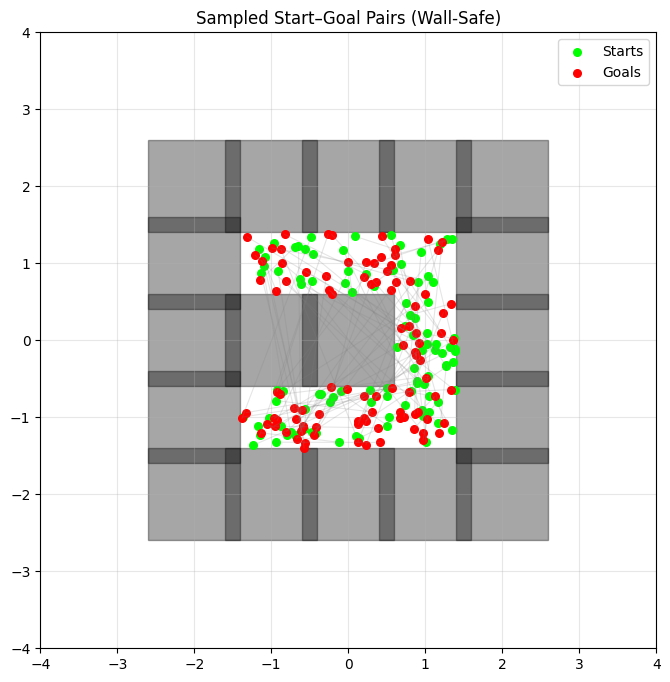

In [ ]:
starts, goals, walls = sample_start_goal_pairs(mj_model_umaze, n=100, inflation=.1, xlim=(-2.5, 2.5), ylim=(-2.5, 2.5))
plot_start_goals_on_maze(mj_model_umaze, starts, goals, walls)


In [25]:
import numpy as np
from pathlib import Path

def save_start_goal_pairs(path, starts, goals):
    """
    Save start–goal pairs only.

    starts: (N, 2)
    goals:  (N, 2)
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    np.savez(
        path,
        starts=starts.astype(np.float32),
        goals=goals.astype(np.float32),
    )

    print(f"[saved] {path} | {len(starts)} pairs")

In [ ]:
starts, goals, _ = sample_start_goal_pairs(
    mj_model_medium,
    n=100,
    xlim=(-4.0, 4.0),
    ylim=(-4.0, 4.0),
    inflation=0.1,
)

save_start_goal_pairs(
    "start_goal/medium_start_goal_100.npz",
    starts,
    goals,
)


[saved] start_goal/medium_start_goal_100.npz | 100 pairs


In [ ]:
data = np.load("start_goal/medium_start_goal_100.npz")
starts = data["starts"]   # (N,2)
goals  = data["goals"]    # (N,2)

In [ ]:
starts, goals, _ = sample_start_goal_pairs(
    mj_model_umaze,
    n=100,
    xlim=(-2.5, 2.5),
    ylim=(-2.5, 2.5),
    inflation=0.1,
)

save_start_goal_pairs(
    "start_goal/umaze_start_goal_100.npz",
    starts,
    goals,
)
data = np.load("start_goal/umaze_start_goal_100.npz")
starts = data["starts"]   # (N,2)
goals  = data["goals"]    # (N,2)


[saved] start_goal/umaze_start_goal_100.npz | 100 pairs


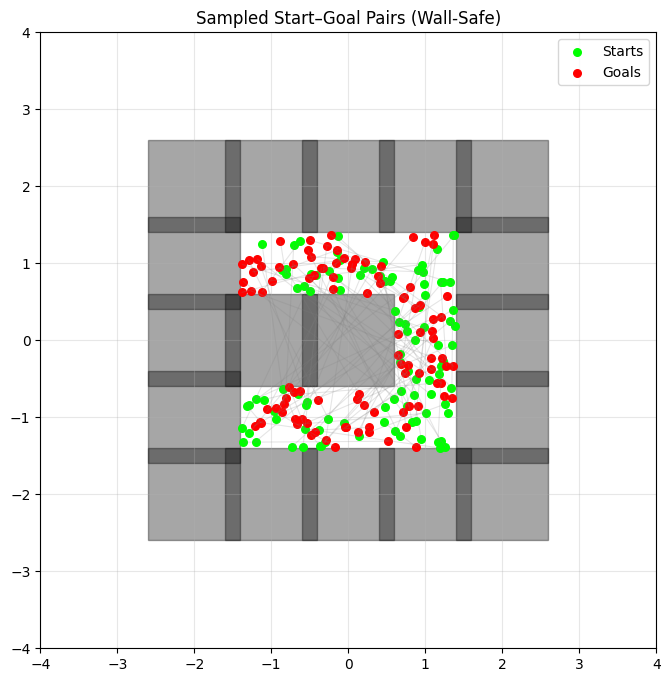

In [ ]:
plot_start_goals_on_maze(mj_model_umaze, starts, goals, walls)


In [21]:
dataset = MinariTrajectoryDatasetWithPseudoActions(
    "D4RL/pointmaze/open-v2", horizon=32, n_chunks_frac= 0.5
)
print(f"\nDataset size: {len(dataset)} trajectory windows")
print(f"Trajectory dim (pos+skip): {dataset.traj_dim}")


Dataset size: 250383 trajectory windows
Trajectory dim (pos+skip): 3


In [22]:
env = dataset.dataset.recover_environment()

def unwrap_env(env):
    while hasattr(env, "env"):
        env = env.env
    return env

env = unwrap_env(env)

mj_model_open = env.model


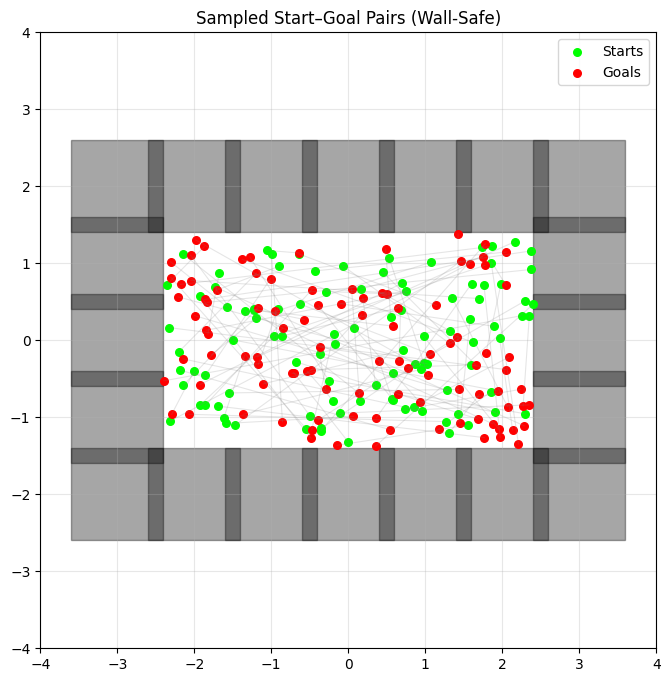

In [23]:
starts, goals, walls = sample_start_goal_pairs(mj_model_open, n=100, inflation=.1, xlim=(-2.5, 2.5), ylim=(-2.5, 2.5))
plot_start_goals_on_maze(mj_model_open, starts, goals, walls)


In [26]:
save_start_goal_pairs(
    "start_goal/open_start_goal_100.npz",
    starts,
    goals,
)


[saved] start_goal/open_start_goal_100.npz | 100 pairs


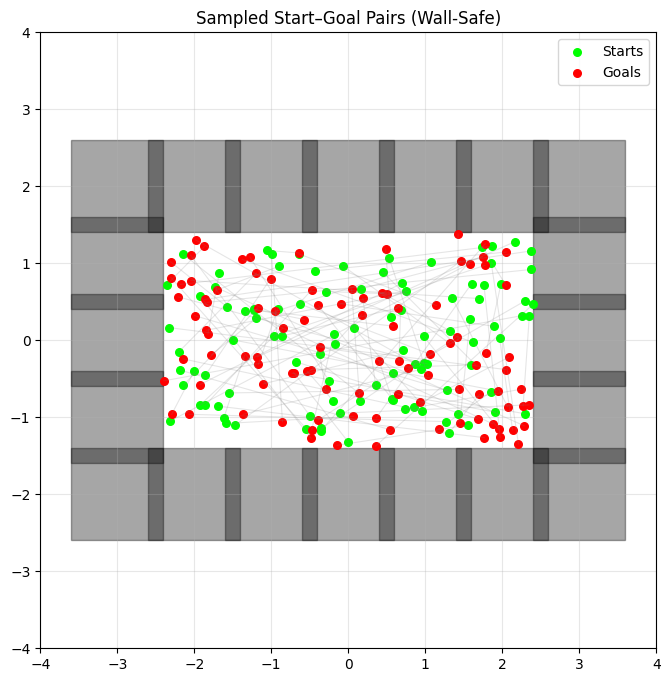

In [27]:
data = np.load("start_goal/open_start_goal_100.npz")
starts = data["starts"]   # (N,2)
goals  = data["goals"]    # (N,2)
plot_start_goals_on_maze(mj_model_open, starts, goals, walls)
